In [157]:
cities <- read.csv("cities-in-region.csv")[,1]
countries <- read.csv("../../02_wwa-private/heat-health-impacts/850-cities/00_paper/00_clean-copy/countries-sorted.csv")
cities <- rev(paste0(countries$CNTR_CODE[countries$CNTR_CODE %in% substr(cities,1,2)],"001C"))

In [158]:
city_names <- read.csv("../../02_wwa-private/heat-health-impacts/850-cities/city_coords.csv", row.names = "URAU_CODE")[cities, "LABEL"]

# Tables for doc

## Event magnitude & RP

In [159]:
rp <- sapply(c("tx3x", "tx3x-june", "tn3x", "tn3x-june"), function(varnm) {
    
    res <- c(sapply(list.files("res", pattern = paste0(varnm,"_.+era5_ev"), full.names = T), 
           function(fnm) {
               r <- signif(read.csv(fnm, row.names = "X")["return_period",], 3)
               paste0(r[1], " (", r[2],", ", r[3], ")")
            }))
    res
    setNames(res, gsub(paste0(".+",varnm,"_|_era5.+"), "", names(res)))
})[cities,]

In [160]:
ev_max <- sapply(c("tx3x", "tx3x-june", "tn3x", "tn3x-june"), function(varnm) {
    
    # flag if event was maximum in time series
    df <- read.csv(paste0("ts/",varnm,"_per-capital_era5.csv"), row.names = "year")[,cities]
    res <- c(df["2026",] == apply(df, 2, max))
    setNames(res, cities)
    
})[cities,]

In [161]:
any(ev_max[,"tx3x"] & ! ev_max[,"tx3x-june"])
any(ev_max[,"tn3x"] & ! ev_max[,"tn3x-june"])

[1] FALSE

[1] FALSE

In [162]:
colSums(ev_max)

tx3x tx3x-june      tn3x tn3x-june 
        9        18        10        16

In [163]:
ev <- sapply(c("tx3x", "tn3x"), function(varnm) {
    
    res <- c(sapply(list.files("res", pattern = paste0(varnm,"_.+era5_ev"), full.names = T), 
           function(fnm) {
               r <- signif(read.csv(fnm, row.names = "X")["event_magnitude","est"], 4)
            }))
    
    setNames(res, gsub(paste0(".+",varnm,"_|_era5.+"), "", names(res)))
})[cities,]

ev[,"tx3x"] <- paste0(ev[,"tx3x"], c("","*")[ev_max[,"tx3x"]+1])
ev[,"tx3x"] <- paste0(ev[,"tx3x"], c("","*")[ev_max[,"tx3x-june"]+1])

ev[,"tn3x"] <- paste0(ev[,"tn3x"], c("","*")[ev_max[,"tn3x"]+1])
ev[,"tn3x"] <- paste0(ev[,"tn3x"], c("","*")[ev_max[,"tn3x-june"]+1])

In [164]:
tbl <- data.frame("ev_tx3x" = ev[,"tx3x"], "rp_tx3x-june" = rp[,"tx3x-june"], "rp_tx3x" = rp[,"tx3x"],
                  "ev_tn3x" = ev[,"tn3x"], "rp_tn3x-june" = rp[,"tn3x-june"], "rp_tn3x" = rp[,"tn3x"])[cities,]
rownames(tbl) <- city_names
write.csv(tbl, "tbl-per-capital_ev.csv")
tbl

,ev_tx3x,rp_tx3x.june,rp_tx3x,ev_tn3x,rp_tn3x.june,rp_tn3x
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Oslo,25.84,"4.36 (2.11, 11.6)","1.66 (1.23, 2.42)",15.88,"8.32 (4.3, 29)","1.33 (1.1, 2.09)"
Stockholm,28.07*,"84.2 (19.3, Inf)","4.84 (2.9, 11.2)",18.45*,"38 (12.3, 2700)","2 (1.37, 3.55)"
Copenhagen,29.27*,"37.5 (7.69, Inf)","3.88 (1.9, 8.53)",19.4*,"161 (43.8, Inf)","5.29 (2.77, 15.5)"
London,32.73**,"65.5 (21.5, Inf)","11.2 (5.45, 35.6)",21.07**,"331 (64.9, Inf)","138 (26.8, Inf)"
Dublin,25.37*,"145 (32.9, Inf)","14.1 (5.43, 46.9)",15.76,"9.8 (5.37, 48.7)","2.06 (1.37, 3.43)"
Paris,38.08**,"188 (44.9, Inf)","19.4 (7.26, 78.1)",25.57**,"213 (48.1, 9.01e+14)","247 (55, Inf)"
Brussels,35.81**,"192 (37.7, Inf)","17.3 (7.07, 103)",23.71**,"1130 (103, Inf)","165 (45.4, Inf)"
Amsterdam,32.21*,"119 (24.9, Inf)","6.86 (3.13, 55.3)",20.85*,"238 (36.8, Inf)","9.48 (3.87, 31.1)"
Luxembourg,36.36**,"319 (49.5, Inf)","24 (10.7, 103)",23.07**,"250 (54.9, Inf)","53.8 (21.4, 723)"


## Change in intensity

In [ ]:
resnm <- "dI_abs_2003"

synth <- read.csv(paste0("obs-synth_",resnm,".csv"), row.names = "X")

tbl <- sapply(c("tx3x", "tx3x-june", "tn3x", "tn3x-june"), function(varnm) {
    df <- round(synth[grepl(paste0(varnm, "_"), rownames(synth)),], 1)
    sapply(1:nrow(df), function(i) {
        r <- df[i,]
        
        stars <- ""
        if (r[1] > 1.2) stars <- paste0(stars, "*")
        
        paste0(r[1], " (", r[2],", ", r[3], ")", stars)
    })
}, simplify = T)
colnames(tbl) <- paste0(resnm,"_",colnames(tbl))
rownames(tbl) <- gsub(".+_","",rownames(synth))[1:19]
tbl <- tbl[cities,c(2,1,4,3)]
rownames(tbl) <- city_names

write.csv(tbl, paste0("tbl-per-capital_",gsub("_","-",resnm),".csv"))
tbl

In [148]:
synth_est <- sapply(c("tx3x", "tx3x-june", "tn3x", "tn3x-june"), function(varnm) {
    df <- round(synth[grepl(paste0(varnm, "_"), rownames(synth)),1], 1)
})[,c(2,1,4,3)]

In [156]:
colSums(synth_est > 1.2)

tx3x-june      tx3x tn3x-june      tn3x 
       15        14        13         5

In [154]:
sum((synth_est[, "tx3x-june"] - synth_est[, "tx3x"]) > 0.2)
sum((synth_est[, "tn3x-june"] - synth_est[, "tn3x"]) > 0.2)

[1] 12

[1] 15

In [155]:
sum((synth_est[, "tx3x-june"] - synth_est[, "tn3x-june"]) > 0.2)
sum((synth_est[, "tx3x"] - synth_est[, "tn3x"]) > 0.2)

[1] 15

[1] 13

# Experimental model fitting

In [ ]:
suppressMessages({library("rwwa"); library("fitdistcp")})

In [ ]:
cities <- sort(read.csv("cities-in-region.csv")[,1])
countries <- read.csv("../../02_wwa-private/heat-health-impacts/850-cities/00_paper/00_clean-copy/countries-sorted.csv")
cities <- paste0(countries$CNTR_CODE[countries$CNTR_CODE %in% substr(cities,1,2)],"001C")

rp <- sapply(c("tx3x", "tx3x-june", "tn3x", "tn3x-june"), function(varnm) {
    res <- c(sapply(list.files("res", pattern = paste0(varnm,"_.+era5_ev"), full.names = T), 
           function(fnm) {
               r <- signif(read.csv(fnm, row.names = "X")["return_period",], 3)
               paste0(r[1], " (", r[2],", ", r[3], ")")
            }))
    res
    setNames(res, gsub(paste0(".+",varnm,"_|_era5.+"), "", names(res)))
})[rev(cities),]


ev <- sapply(c("tx3x", "tn3x"), function(varnm) {
    res <- c(sapply(list.files("res", pattern = paste0(varnm,"_.+era5_ev"), full.names = T), 
           function(fnm) {
               r <- round(read.csv(fnm, row.names = "X")["event_magnitude","est"], 1)
            }))
    res
    setNames(res, gsub(paste0(".+",varnm,"_|_era5.+"), "", names(res)))
})[rev(cities),]

In [8]:
data.frame(ev[,"tx3x"], rp[,"tx3x-june"], rp[,"tx3x"], ev[,"tn3x"], rp[,"tn3x-june"], rp[,"tn3x"])

,ev....tx3x..,rp....tx3x.june..,rp....tx3x..,ev....tn3x..,rp....tn3x.june..,rp....tn3x..
,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>
NO001C,26.0,"4.63 (2.2, 12.5)","1.72 (1.26, 2.54)",16.1,"9.94 (4.94, 40.7)","1.41 (1.13, 2.4)"
SE001C,29.7,"265 (42.7, Inf)","13.3 (6.53, 121)",19.7,"192 (40.5, Inf)","4.91 (2.43, 13.4)"
DK001C,30.4,"149 (23, Inf)","8.32 (3.32, 34.9)",20.5,"328 (68.9, Inf)","21.1 (7.52, 357)"
UK001C,32.2,"48.7 (17.3, 167000)","8.29 (4.18, 23)",21.1,"333 (65.2, Inf)","140 (27, Inf)"
IE001C,24.7,"66.4 (18.9, Inf)","7.99 (3.44, 23.8)",16.3,"19.7 (9.1, 235)","3.56 (2.15, 6.96)"
FR001C,38.1,"187 (44.7, Inf)","19.3 (7.21, 77.7)",25.5,"207 (47.3, 3.5e+12)","235 (52.7, Inf)"
BE001C,36.6,"340 (50.8, Inf)","32.4 (11.6, 368)",23.7,"1140 (103, Inf)","167 (46, Inf)"
NL001C,32.9,"199 (35.5, Inf)","11.7 (4.6, 403)",21.2,"321 (44.1, Inf)","13.5 (5.11, 51.4)"
LU001C,36.5,"357 (52.2, Inf)","27 (11.9, 131)",23.5,"309 (61.8, Inf)","72.6 (26.7, 2240)"


In [3]:
# wrapper function to fit model, get parameter ests, RPs & PRs
fit_cp <- function(data, covnm = "gmst", varnm = "x", cov_f, cov_cf, ev_year, nsamp = 1000, seed = 42) {

    if(missing(ev_year)) ev_year <- max(data$year)
    
    # assume GEV for now
    set.seed(seed)
    theta_samp <- tgev_p1_cp(nsamp, x = data[,varnm], t = data[,covnm])$theta_samples
    colnames(theta_samp) <- c("mu0", "alpha_gmst", "sigma0", "shape")

    ev <- data[data$year == ev_year, varnm]

    # calculate the other quantities we need for all parameter samples
    cp_ests <- t(apply(theta_samp, 1, function(pars) {
        ep_f <- 1-pevd(ev, loc = pars[1]+pars[2]*unlist(cov_f), scale = pars[3], shape = pars[4])
        ep_cf <- 1-pevd(ev, loc = pars[1]+pars[2]*unlist(cov_cf), scale = pars[3], shape = pars[4])

        rp_f <- 1/ep_f
        rp_cf <- 1/ep_cf
        pr <- ep_f / ep_cf
        nll <- sum(devd(data[,varnm], loc = pars[1]+pars[2]*data[,covnm], scale = pars[3], shape = pars[4], log = T))
        c("ep_f" = ep_f, "ep_cf" = ep_cf, "rp_f" = rp_f, "rp_cf" = rp_cf, "pr" = pr, "aic" = -2*(nll + ncol(theta_samp)))
    }))
    data.frame(cbind(theta_samp, cp_ests))
}


## Fit models

In [8]:
fnm <- "era_ann_tx"
ev_year <- 2026

fpath <- "~/00_WWA_project_folder/ephemeral/euro_heat/time_series/"

In [9]:
ts <- read.csv(paste0(fpath,fnm,".csv"), col.names = c("year", "x"))

gmst <- read.table("data/gmst.dat", col.names = c("year", "gmst"))
gmst$gmst <- gmst$gmst - gmst$gmst[gmst$year == ev_year]
df <- merge(gmst, ts)

cov_ev <- gmst[gmst$year == ev_year,"gmst",drop = F]
cov_cf <- data.frame(cov_ev -1.4)

In [ ]:
# max likelihood
ns_gev <- fit_ns("gev", "shift", data = df, varnm = "x", covnm = "gmst", lower = F, ev_year = ev_year)
ns_norm <- fit_ns("norm", "shift", data = df, varnm = "x", covnm = "gmst", lower = F, ev_year = ev_year)

boot_gev <- boot_ci(ns_gev, cov_f = cov_ev, cov_cf = cov_cf, return_sample = T)
boot_gev[is.na(boot_gev)] <- Inf

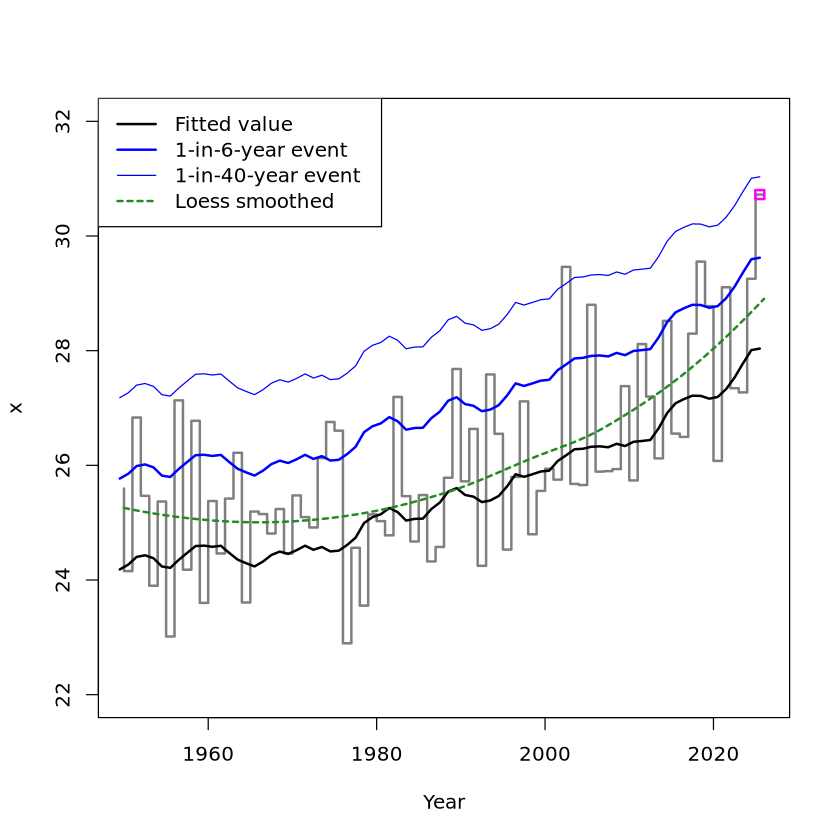

In [12]:
plot_trend(ns_gev)

In [ ]:
# calibrating priors
set.seed(42)
cp_theta <- tgev_p1_cp(1000, x = df$x, t = df$gmst)$theta_samples   # sample from posterior parameter vector

Warning message in ru(gev_p1_logf, x = x, t = t, n = n, d = 4, init = c(0, 0, 1, :
“The Hessian of the target log-density at its mode is not positive
            definite. This may not be a problem, but it may be that a mode
            at/near a parameter boundary has been found and/or that the target
            function is unbounded.”


  It might be worth using the option trans = ``BC''. 


Warning message in ru(gev_p1_logf, x = x, t = t, n = n, d = 4, init = c(0, 0, 1, :
“rotate has been changed to FALSE.”


In [14]:
set.seed(42)
cp_qgev <- qgev_p1_cp(x = df$x, t = df$gmst, t0 = cov_ev$gmst)

In [15]:
cp_returnperiod <- apply(cp_theta, 1, function(pars) {
    1/(1-pevd(ns_gev$ev, loc = pars[1]+pars[2]*unlist(cov_ev), scale = pars[3], shape = pars[4]))
})

cp_pr <- apply(cp_theta, 1, function(pars) {
    rp_f <- 1/(1-pevd(ns_gev$ev, loc = pars[1]+pars[2]*unlist(cov_ev), scale = pars[3], shape = pars[4]))
    rp_cf <- 1/(1-pevd(ns_gev$ev, loc = pars[1]+pars[2]*unlist(cov_cf), scale = pars[3], shape = pars[4]))
    rp_cf / rp_f
})

cp_nll <- apply(cp_theta, 1, function(pars) {
    sum(devd(df$x, loc = pars[1]+pars[2]*unlist(cov_ev), scale = pars[3], shape = pars[4], log = T))
})

ERROR: Error: object 'cp_theta' not found


In [ ]:
# default priors from extRemes
ns_extR <- fevd(df$x, data = df, location.fun = ~gmst, method = "Bayesian")
extR_theta <- ns_extR$results[-(1:5000),1:4]

extR_returnperiod <- apply(extR_theta, 1, function(pars) {
    1/(1-pevd(ns_gev$ev, loc = pars[1]+pars[2]*unlist(cov_ev), scale = exp(pars[3]), shape = pars[4]))
})

extR_pr <- apply(extR_theta, 1, function(pars) {
    rp_f <- 1/(1-pevd(ns_gev$ev, loc = pars[1]+pars[2]*unlist(cov_ev), scale = exp(pars[3]), shape = pars[4]))
    rp_cf <- 1/(1-pevd(ns_gev$ev, loc = pars[1]+pars[2]*unlist(cov_cf), scale = exp(pars[3]), shape = pars[4]))
    rp_cf / rp_f
})

extR_nll <- apply(extR_theta, 1, function(pars) {
    sum(devd(df$x, loc = pars[1]+pars[2]*unlist(cov_ev), scale = exp(pars[3]), shape = pars[4], log = T))
})

## Compare parameter estimates

In [ ]:
# compare density of parameter estimates
prep_window(c(2,3))

plot(density(boot_gev["mu0",]), main = "mu0")
lines(density(cp_theta[,1]), col = "blue")
lines(density(extR_theta[,1]), col = "red3")
rug(mdl_ests(ns_gev, cov_f = cov_ev, cov_cf = cov_cf)["mu0"], lwd = 4)
rug(mean(cp_theta[,1]), col = "skyblue", lwd = 4)
rug(median(cp_theta[,1]), col = "blue", lwd = 4)
rug(median(extR_theta[,1]), col = "red3", lwd = 4)

plot(density(boot_gev["alpha_gmst",]), main = "alpha_gmst")
lines(density(cp_theta[,2]), col = "blue")
lines(density(extR_theta[,2]), col = "red3")
rug(mdl_ests(ns_gev, cov_f = cov_ev, cov_cf = cov_cf)["alpha_gmst"], lwd = 4)
rug(mean(cp_theta[,2]), col = "skyblue", lwd = 4)
rug(median(cp_theta[,2]), col = "blue", lwd = 4)
rug(median(extR_theta[,2]), col = "red3", lwd = 4)

plot(density(boot_gev["sigma0",]), main = "sigma0")
lines(density(cp_theta[,3]), col = "blue")
lines(density(exp(extR_theta[,3])), col = "red3")
rug(mdl_ests(ns_gev, cov_f = cov_ev, cov_cf = cov_cf)["sigma0"], lwd = 4)
rug(median(cp_theta[,3]), col = "blue", lwd = 4)
rug(exp(median(extR_theta[,3])), col = "red3", lwd = 4)

plot(density(boot_gev["shape",]), main = "xi")
lines(density(cp_theta[,4]), col = "blue")
lines(density(extR_theta[,4]), col = "red3")
rug(mdl_ests(ns_gev, cov_f = cov_ev, cov_cf = cov_cf)["shape"], lwd = 4)
rug(median(cp_theta[,4]), col = "blue", lwd = 4)
rug(median(extR_theta[,4]), col = "red3", lwd = 4)

rpdns_ml <- density(boot_gev["return_period",], from = 0, to = 500)
rpdns_cp <- density(cp_returnperiod, from = 0, to = 500)
rpdns_extR <- density(extR_returnperiod, from = 0, to = 500)
plot(rpdns_cp, col = "blue", main = "Return period", ylim = c(0, max(pretty(c(rpdns_ml$y,rpdns_cp$y, rpdns_extR$y)))))
lines(rpdns_ml)
lines(rpdns_extR, col = "red3")
rug(mdl_ests(ns_gev, cov_f = cov_ev, cov_cf = cov_cf)["return_period"], lwd = 4)
rug(mean(cp_returnperiod), col = "skyblue", lwd = 4)
rug(median(cp_returnperiod), col = "blue", lwd = 4)
rug(median(extR_returnperiod), col = "red3", lwd = 4)
points(rep(rpdns_ml$x[which.max(rpdns_ml$y)], 2), c(max(rpdns_ml$y), 0))
points(rep(rpdns_cp$x[which.max(rpdns_cp$y)], 2), c(max(rpdns_cp$y), 0), col = "blue")
points(rep(rpdns_extR$x[which.max(rpdns_extR$y)], 2), c(max(rpdns_extR$y), 0), col = "red3")

prdns_ml <- density(boot_gev["PR",], from = 0, to = 500, na.rm = T)
prdns_cp <- density(cp_pr, from = 0, to = 500)
prdns_extR <- density(extR_pr, from = 0, to = 500)
plot(prdns_cp, col = "blue", main = "Probability ratio", ylim = c(0, max(pretty(c(prdns_ml$y, prdns_cp$y, prdns_extR$y)))))
lines(prdns_ml)
lines(prdns_extR, col = "red3")
rug(mdl_ests(ns_gev, cov_f = cov_ev, cov_cf = cov_cf)["PR"], lwd = 4)
rug(median(cp_pr), col = "blue", lwd = 4)
rug(median(extR_pr), col = "red3", lwd = 4)
points(rep(prdns_ml$x[which.max(prdns_ml$y)], 2), c(max(prdns_ml$y), 0))
points(rep(prdns_cp$x[which.max(prdns_cp$y)], 2), c(max(prdns_cp$y), 0), col = "blue")
points(rep(prdns_extR$x[which.max(prdns_extR$y)], 2), c(max(prdns_extR$y), 0), col = "red3")

## Compare fitted models

In [121]:
# compare log-likelihoods
loc_cp <- cp_gev$ml_params[1] + df$gmst * cp_gev$ml_params[2]
nll_cp <- sum(devd(df$x, loc = loc_cp, scale = cp_gev$ml_params[3], shape = cp_gev$ml_params[4], log = T))

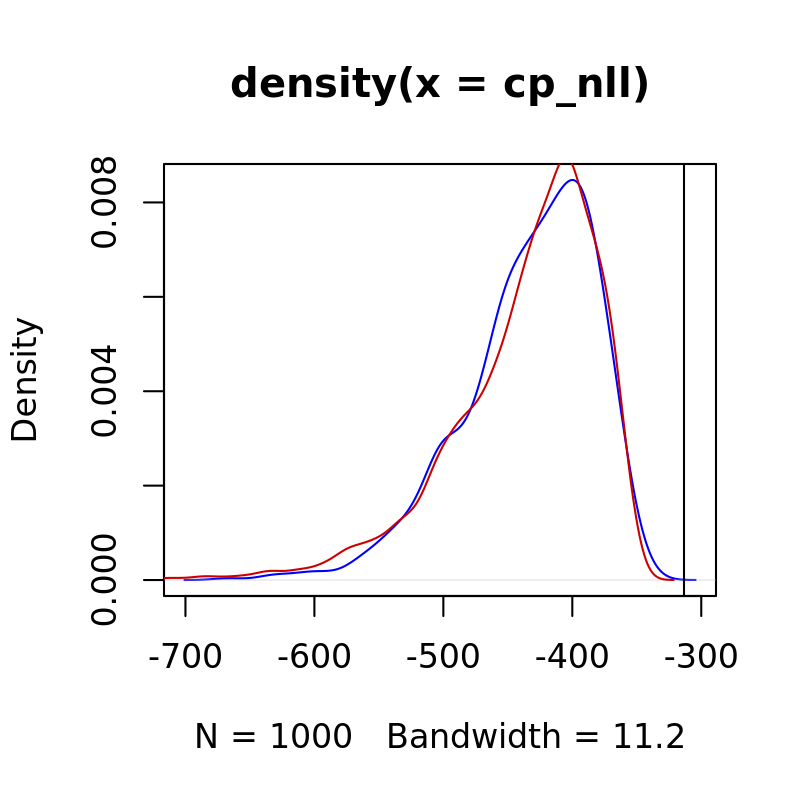

In [122]:
prep_window(c(1,1))

plot(density(cp_nll), col = "blue")
lines(density(extR_nll), col = "red3")
abline(v = -ns_gev$value)

In [ ]:
cp_medpars <- apply(cp_theta, 2, median)

In [ ]:
cp_medloc = cp_medpars[1]+cp_medpars[2]*unlist(cov_ev)

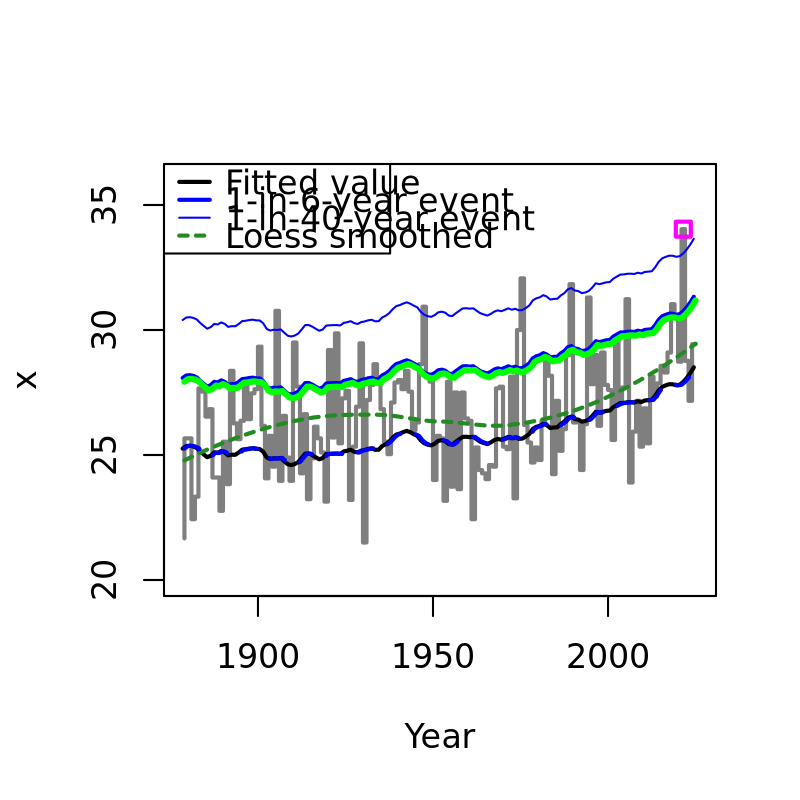

In [161]:
plot_trend(ns_gev)

lines(df$year, loc_cp, col = "blue", lwd = 2, lty = 2)
lines(df$year, cp_qgev$predictedparameter, col = "green", lwd = 3)

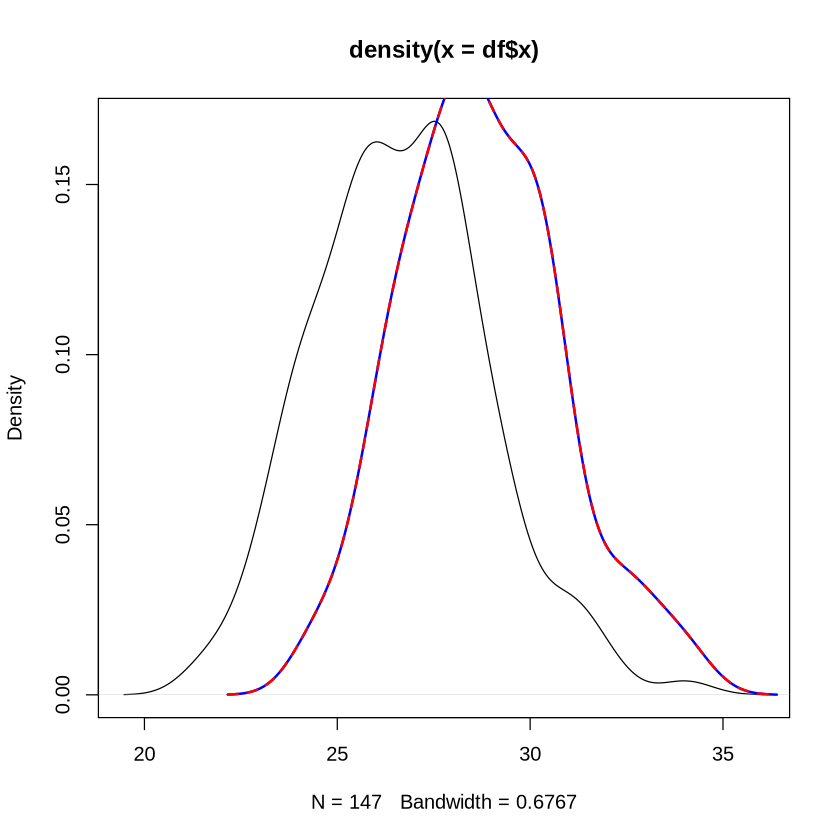

In [247]:
# pdf of transformed points is the same - presumably still using ML estimates?
plot(density(df$x))
lines(density(cp_qgev$adjustedx), col = "blue", lwd = 2)
lines(density(map_from_u(ns_gev, map_to_u(ns_gev), fixed_cov = cov_ev)), col = "red", lty = 2, lwd = 2)

In [ ]:
return_period(ns_gev, ns_gev$ev, fixed_cov = cov_ev)

In [64]:
rbind.fill(list("ns_gev" = data.frame(t(mdl_ests(ns_gev, cov_f = cov_ev, cov_cf = cov_cf))),
                "ns_norm" = data.frame(t(mdl_ests(ns_norm, cov_f = cov_ev, cov_cf = cov_cf)))))

mu0,sigma0,alpha_gmst,shape,disp,event_magnitude,return_period,PR,dI_abs,dI_rel,aic
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
28.50610,1.938136,2.316176,-0.1883314,0.06940474,34.03333,119.6385,0.5033816,-0.5809732,-1.678419,634.7667
29.18776,2.062768,2.204808,NA,0.07203732,34.03333,225.5758,0.4710905,-0.5530385,-1.599007,636.0394


# Compare results

## Compare quantile estimates

In [458]:
apply(theta_cp, 2, quantile, c(0.5, 0.025, 0.975), na.rm = T)

,mu0,alpha_gmst,sigma0,shape,ep_f,ep_cf,rp_f,rp_cf,pr,aic
50%,28.45651,2.299696,1.969888,-0.18031721,0.009681893,0.000165565,103.28560,6040.3511,55.448557,622.1629
2.5%,27.48631,1.472807,1.750290,-0.28113997,0.001092201,0.000000000,29.55886,182.8495,4.828171,619.2619
97.5%,29.42994,3.135596,2.225500,-0.06916032,0.033830804,0.005469054,915.58479,Inf,Inf,629.6014


In [ ]:
rbind("est" = mdl_ests(ns_gev, cov_f = cov_ev, cov_cf = cov_cf), apply(boot_gev, 1, quantile, c(0.5, 0.025, 0.975)))

## Plot parameter ranges

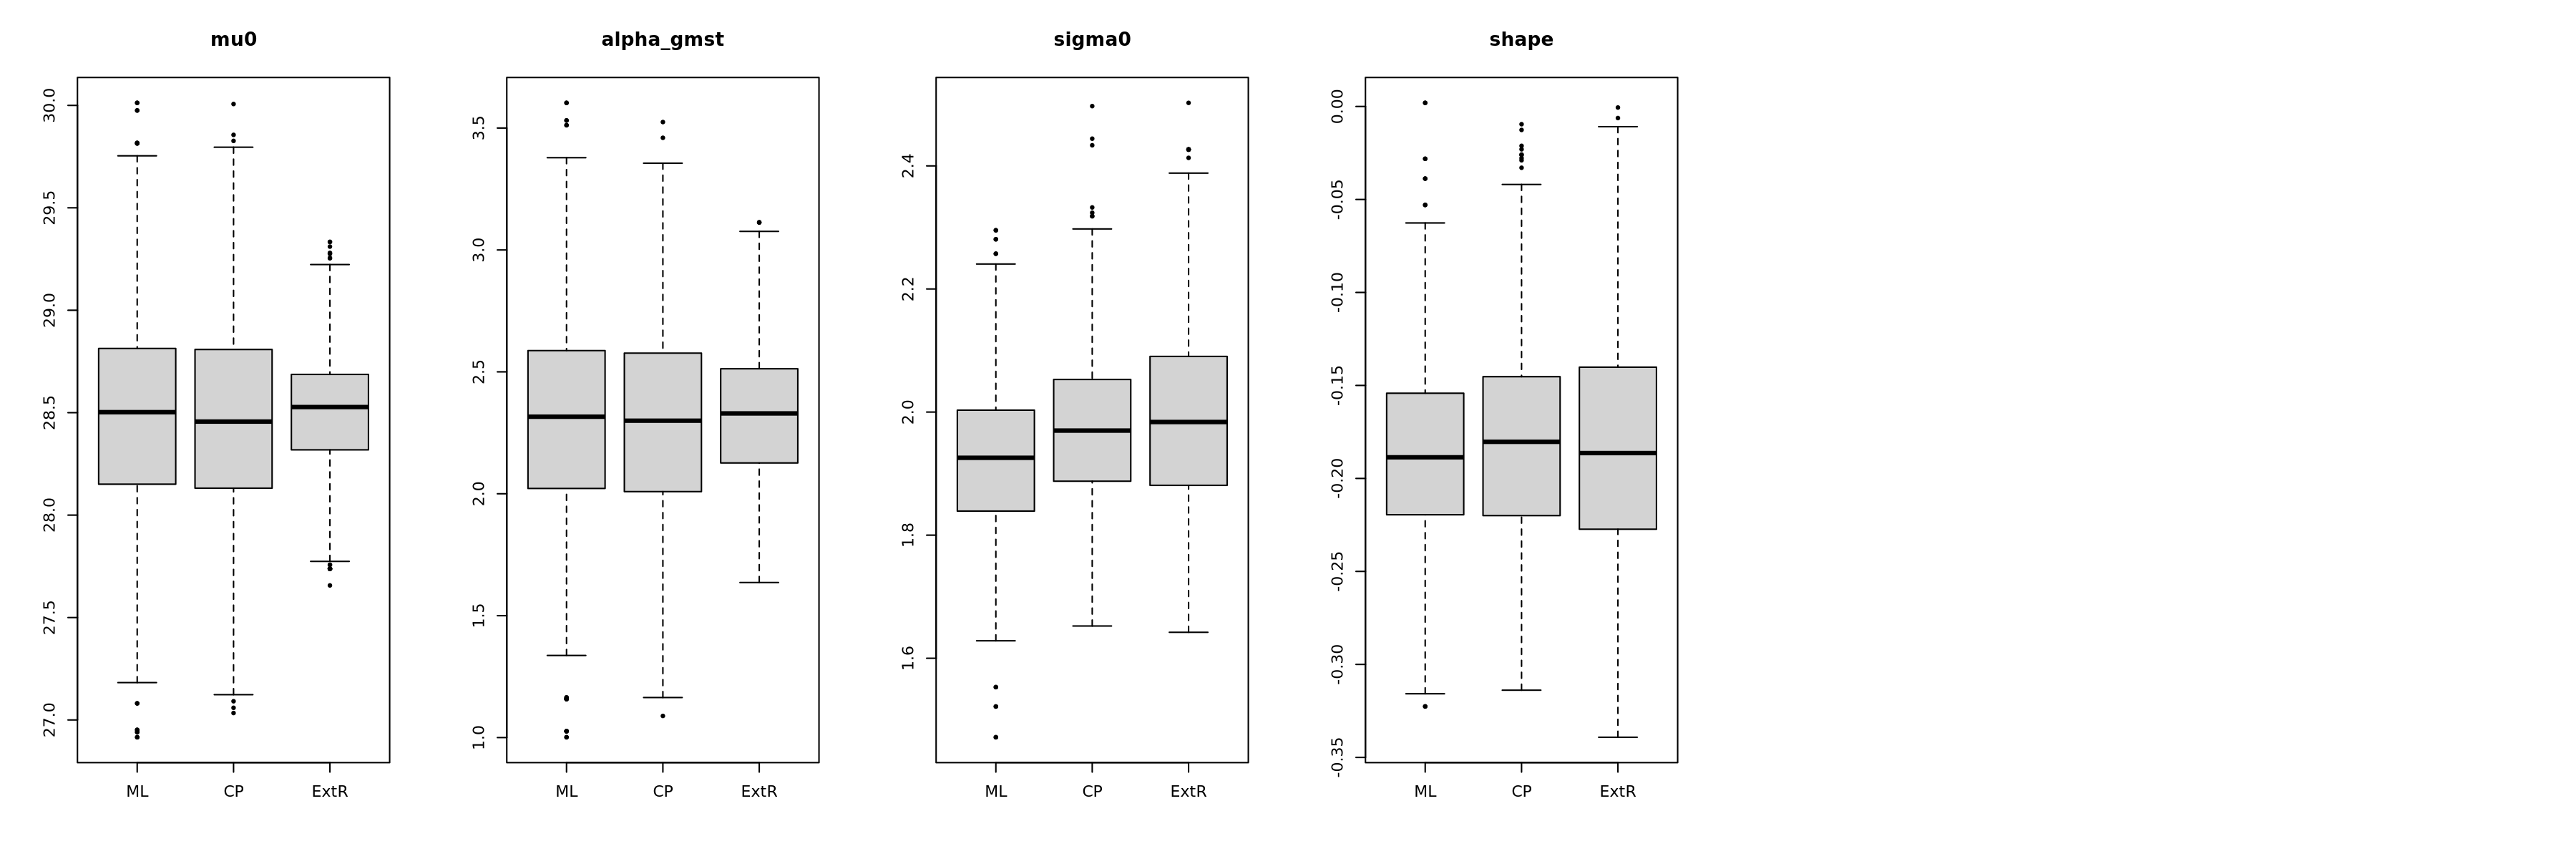

In [176]:
plot_pars <- c("mu0", "alpha_gmst", "sigma0", "shape", "return_period", "pr")
prep_window(c(1,length(plot_pars)), w = 3, h = 6)

boxplot(cbind(boot_gev["mu0",], cp_theta[,1], extR_theta[1:1000,"mu0"]), main = "mu0", names = c("ML", "CP", "ExtR"))
boxplot(cbind(boot_gev["alpha_gmst",], cp_theta[,2], extR_theta[1:1000,"mu1"]), main = "alpha_gmst", names = c("ML", "CP", "ExtR"))
boxplot(cbind(boot_gev["sigma0",], cp_theta[,3], exp(extR_theta[1:1000,3])), main = "sigma0", names = c("ML", "CP", "ExtR"))
boxplot(cbind(boot_gev["shape",], cp_theta[,4], extR_theta[1:1000,"shape"]), main = "shape", names = c("ML", "CP", "ExtR"))

# boxplot(cbind(boot_gev["return_period",], theta_cp["rp_f"]), main = "return_period", names = c("ML", "CP"), ylim = c(0,1000))
# boxplot(cbind(boot_gev["PR",], theta_cp["pr"]), main = "pr", names = c("ML", "CP"), ylim = c(0.1,1000000), log = "y")

# Plots

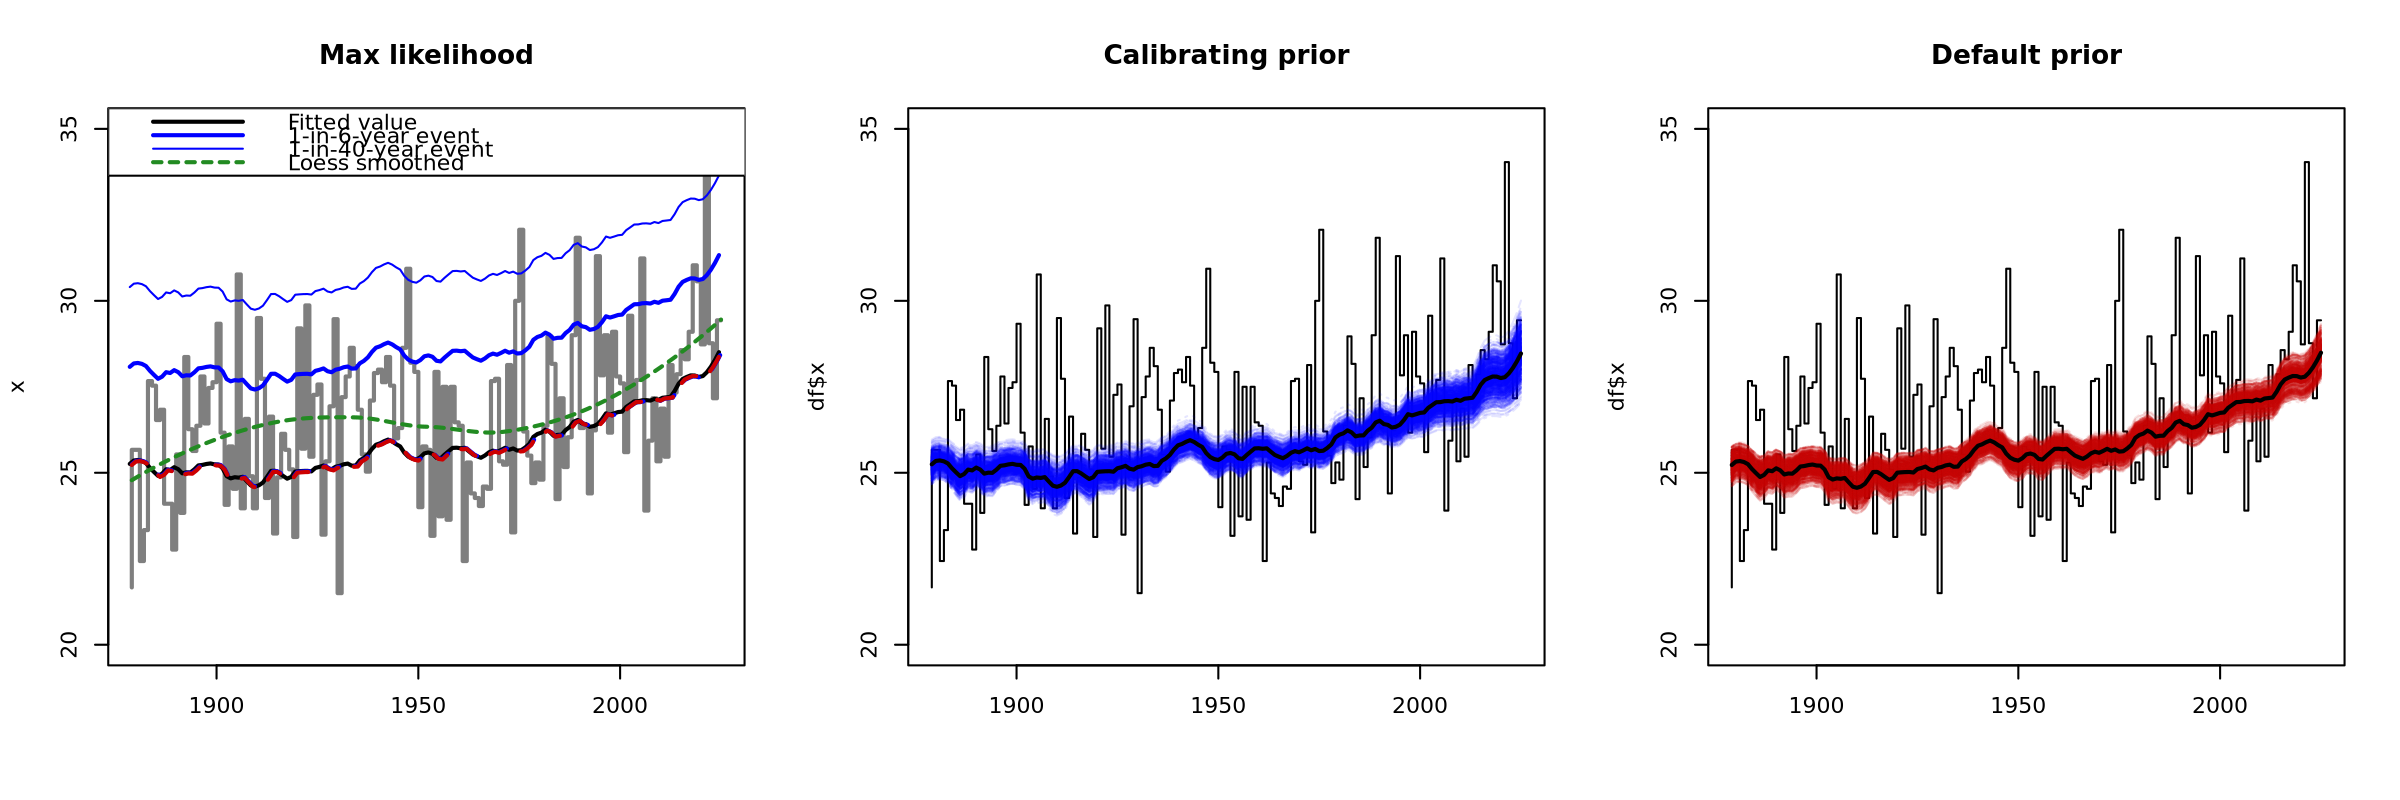

In [202]:
prep_window(c(1,3))
ylim <- c(20,35)

cp_fitted <- apply(cp_theta, 1, function(pars) {pars[1] + pars[2]*df$gmst})
extR_fitted <- apply(extR_theta, 1, function(pars) {pars[1] + pars[2]*df$gmst})[,1:1000]

plot_trend(ns_gev, xlab = "", ylim = ylim, main = "Max likelihood")
lines(df$year, rowMeans(cp_fitted), lwd = 2, col = "blue", lty = 2)
lines(df$year, rowMeans(extR_fitted), lwd = 2, col = "red3", lty = 2)

plot(df$year, df$x, type = "S", xlab = "", ylim = ylim, main = "Calibrating prior")
matplot(df$year, cp_fitted, type = "l", add = T, col = adjustcolor("blue", 0.1))
lines(df$year, rowMeans(cp_fitted), lwd = 2)

plot(df$year, df$x, type = "S", xlab = "", ylim = ylim, main = "Default prior")
matplot(df$year, extR_fitted, type = "l", add = T, col = adjustcolor("red3", 0.1))
lines(df$year, rowMeans(extR_fitted), lwd = 2)


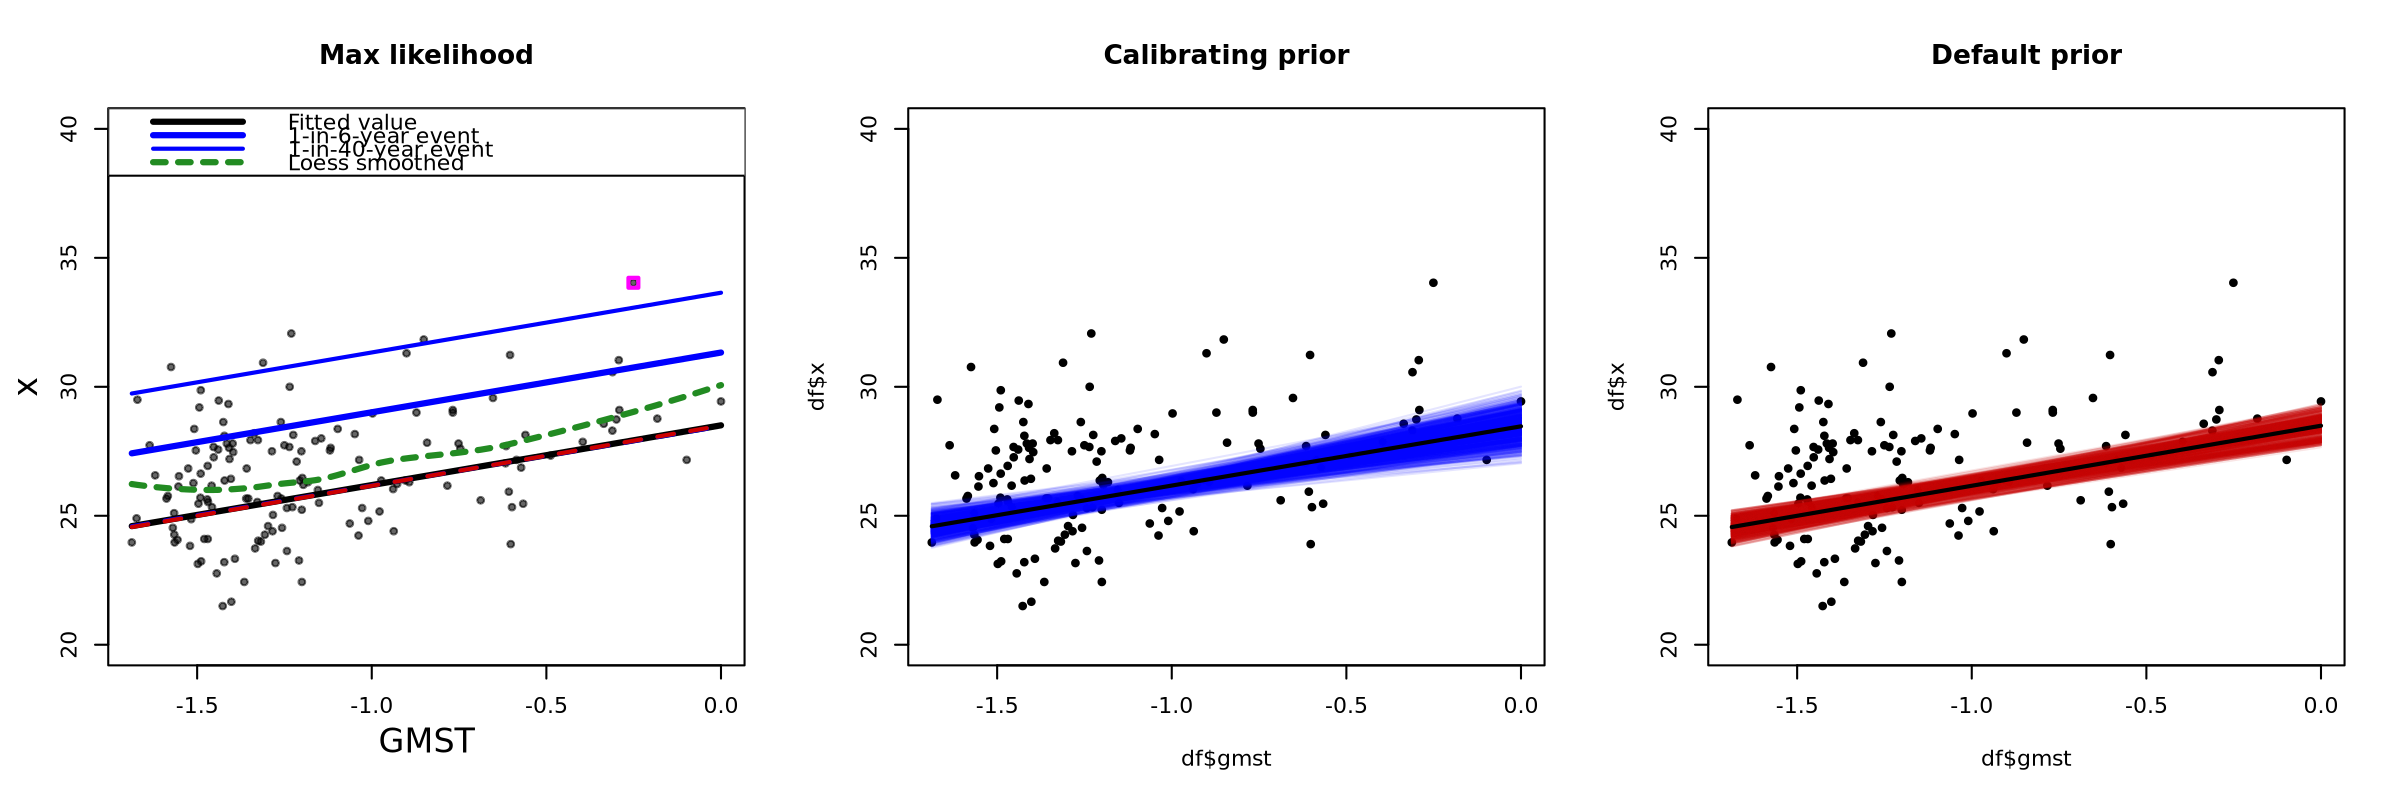

In [212]:
prep_window(c(1,3))
ylim <- c(20,40)
o <- order(df$gmst)

plot_covtrend(ns_gev, xcov = "gmst", ylim = ylim, main = "Max likelihood")
lines(df$gmst[o], rowMeans(cp_fitted)[o], lwd = 2, lty = 2, col = "blue")
lines(df$gmst[o], rowMeans(extR_fitted)[o], lwd = 2, lty = 2, col = "red3")

plot(df$gmst, df$x, ylim = ylim, main = "Calibrating prior")
matplot(df$gmst[o], cp_fitted[o,], type = "l", add = T, col = adjustcolor("blue", 0.1), lty = 1)
lines(df$gmst[o], rowMeans(cp_fitted)[o], lwd = 2)

plot(df$gmst, df$x, ylim = ylim, main = "Default prior")
matplot(df$gmst[o], extR_fitted[o,], type = "l", add = T, col = adjustcolor("red3", 0.1), lty = 1)
lines(df$gmst[o], rowMeans(extR_fitted)[o], lwd = 2)

In [ ]:
rp_x <- unique(c(seq(1.1, 2, 0.1), seq(2, 100, 1), seq(100, 1000, 10), seq(100, 1000, 100), seq(1000, 10000, 1000)))

In [ ]:
qqev_cp <- qgev_p1_cp(x = df$x, t = df$gmst, t0 = cov_ev$gmst, p = 1-(1/rp_x), rust = T)
qqcf_cp <- qgev_p1_cp(x = df$x, t = df$gmst, t0 = cov_cf$gmst, p = 1-(1/rp_x), rust = T)

# calculate the other quantities we need for all parameter samples
rlci_ev_cp <- apply(cp_theta, 1, function(pars) {
    qevd(1-(1/rp_x), loc = pars[1]+pars[2]*unlist(cov_ev), scale = pars[3], shape = pars[4])
})
rlci_cf_cp <- apply(cp_theta, 1, function(pars) {
    qevd(1-(1/rp_x), loc = pars[1]+pars[2]*unlist(cov_cf), scale = pars[3], shape = pars[4])
})

rp_ev_cp <- pgev_p1_cp(x = df$x, t = df$gmst, t0 = cov_ev$gmst, y = df$x[df$year == ev_year], rust = T)
rp_cf_cp <- pgev_p1_cp(x = df$x, t = df$gmst, t0 = cov_cf$gmst, y = df$x[df$year == ev_year], rust = T)

In [ ]:
rlci_ev_extR <- apply(extR_theta, 1, function(pars) {
    qevd(1-(1/rp_x), loc = pars[1]+pars[2]*unlist(cov_ev), scale = exp(pars[3]), shape = pars[4])
})
rlci_cf_extR <- apply(extR_theta, 1, function(pars) {
    qevd(1-(1/rp_x), loc = pars[1]+pars[2]*unlist(cov_cf), scale = exp(pars[3]), shape = pars[4])
})

In [ ]:
prep_window(c(1,3))
plot_returnlevels(ns_gev, cov_f = cov_ev, cov_cf = cov_cf, nsamp = 10, ylim = c(20,45), main = "Maximum likelihood")

lines(rp_x, qqev_cp$cp_quantiles, lty = 2)
lines(rp_x, qqcf_cp$cp_quantiles, lty = 2)

lines(rp_x, rowMeans(rlci_ev_extR), lty = 3)
lines(rp_x, rowMeans(rlci_cf_extR), lty = 3)

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~#
plot(rp_x, qqev_cp$cp_quantiles, ylim = c(20,45), log = "x", type = "l", col = "firebrick", main = "Calibrating priors")

polygon(x = c(rp_x, rev(rp_x)), y = c(apply(rlci_ev_cp, 1, quantile, 0.025), 
            rev(apply(rlci_ev_cp, 1, quantile, 0.975))), density = NULL, 
            border = NA, col = adjustcolor("firebrick", 0.1))
polygon(x = c(rp_x, rev(rp_x)), y = c(apply(rlci_cf_cp, 1, quantile, 0.025), 
            rev(apply(rlci_cf_cp, 1, quantile, 0.975))), density = NULL, 
            border = NA, col = adjustcolor("blue", 0.1))

rug(1/(1-rp_ev_cp$ru_cdf), col = "firebrick", lwd = 3)
rug(1/(1-rp_cf_cp$ru_cdf), col = "blue", lwd = 3)

# matplot(rp_x, rl_conf_ev, type = "l", lty = 1, col = adjustcolor("red", 0.1), log = "x", ylim = c(20,45))
# matplot(rp_x, rl_conf_cf, type = "l", lty = 1, col = adjustcolor("blue", 0.1), add = T)

lines(rp_x, qqev_cp$cp_quantiles, col = "firebrick", lwd = 2)
lines(rp_x, qqcf_cp$cp_quantiles, col = "blue", lwd = 2)

points(1/seq(1, 0, length.out = nrow(df) + 2)[2:(nrow(df) + 1)], sort(qqev_cp$adjustedx), col = "firebrick")
points(1/seq(1, 0, length.out = nrow(df) + 2)[2:(nrow(df) + 1)], sort(qqcf_cp$adjustedx), col = "blue")

abline(h = df$x[df$year == ev_year], col = "magenta", lty = 2)

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~#
plot(rp_x, rowMeans(rlci_ev_extR), ylim = c(20,45), log = "x", type = "l", col = "firebrick", main = "Default priors")

polygon(x = c(rp_x, rev(rp_x)), y = c(apply(rlci_ev_extR, 1, quantile, 0.025), 
            rev(apply(rlci_ev_extR, 1, quantile, 0.975))), density = NULL, 
            border = NA, col = adjustcolor("firebrick", 0.1))
polygon(x = c(rp_x, rev(rp_x)), y = c(apply(rlci_cf_extR, 1, quantile, 0.025), 
            rev(apply(rlci_cf_extR, 1, quantile, 0.975))), density = NULL, 
            border = NA, col = adjustcolor("blue", 0.1))

lines(rp_x, rowMeans(rlci_ev_extR), col = "firebrick", lwd = 2)
lines(rp_x, rowMeans(rlci_cf_extR), col = "blue", lwd = 2)

abline(h = df$x[df$year == ev_year], col = "magenta", lty = 2)

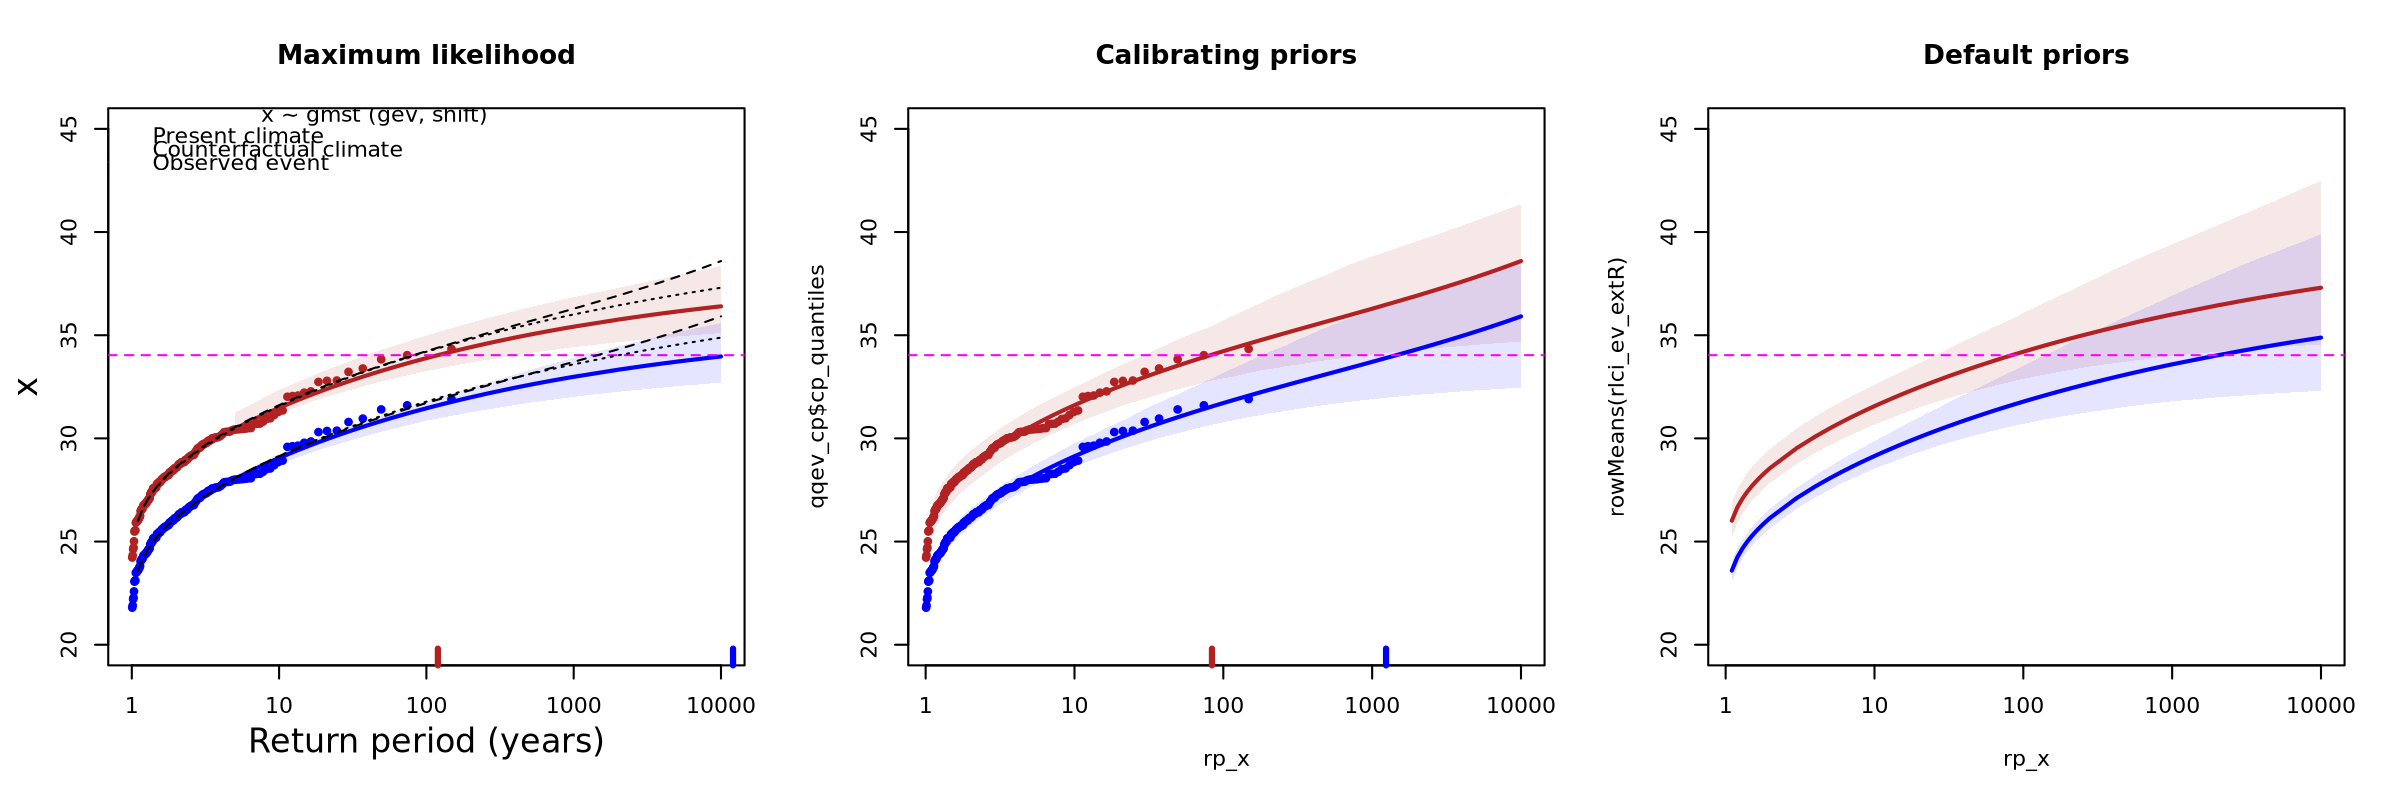

In [ ]:
pevd(df$x[df$year == ev_year], )

# Quick run & save results

In [158]:
fnm <- "fennoscandia-tx14x-era5"

ev_year <- list("brazil-rx4day-mswx" = 2024,
                "cet-tx3x" = 2022,
                "fennoscandia-tx14x-era5" = 2025,
               "pnw-vancouver-tx3x" = 2021)[[fnm]]

In [159]:
ts <- read.csv(paste0("ts/",fnm,".csv"), col.names = c("year", "x"))

gmst <- read.table("ts/gmst.txt", col.names = c("year", "gmst"))
gmst$gmst <- gmst$gmst - gmst$gmst[gmst$year == 2025]
df <- merge(gmst, ts)

cov_ev <- gmst[gmst$year == ev_year,"gmst",drop = F]
cov_cf <- data.frame(gmst = -1.3)

In [160]:
# max likelihood
ns_gev <- fit_ns("gev", "shift", data = df, varnm = "x", covnm = "gmst", lower = F, ev_year = ev_year)
boot_gev <- boot_ci(ns_gev, cov_f = cov_ev, cov_cf = cov_cf, return_sample = T)
boot_gev[is.na(boot_gev)] <- Inf

# calibrating priors
theta_cp <- fit_cp(df, covnm = "gmst", varnm = "x", cov_f = cov_ev, cov_cf = cov_cf, ev_year = ev_year)

In [161]:
# estimates of location per year
loc_cp <- apply(theta_cp, 1, function(pars) { pars["mu0"] + pars["alpha_gmst"]*df$gmst })

In [162]:
# elements for return level plots
rp_x <- unique(c(seq(1.1, 2, 0.1), seq(2, 100, 1), seq(100, 1000, 10), seq(100, 1000, 100), seq(1000, 10000, 1000)))
qqev_cp <- qgev_p1_cp(x = df$x, t = df$gmst, t0 = cov_ev$gmst, p = 1-(1/rp_x), rust = T)
qqcf_cp <- qgev_p1_cp(x = df$x, t = df$gmst, t0 = cov_cf$gmst, p = 1-(1/rp_x), rust = T)

rl_conf_ev <- apply(theta_cp, 1, function(pars) {
    qevd(1-(1/rp_x), loc = pars[1]+pars[2]*unlist(cov_ev), scale = pars[3], shape = pars[4])
})
rl_conf_cf <- apply(theta_cp, 1, function(pars) {
    qevd(1-(1/rp_x), loc = pars[1]+pars[2]*unlist(cov_cf), scale = pars[3], shape = pars[4])
})

rp_ev <- pgev_p1_cp(x = df$x, t = df$gmst, t0 = cov_ev$gmst, y = df$x[df$year == ev_year], rust = T)
rp_cf <- pgev_p1_cp(x = df$x, t = df$gmst, t0 = cov_cf$gmst, y = df$x[df$year == ev_year], rust = T)

## Boxplots of parameter estimates

In [163]:
png(paste0("fig/",fnm,"_par-boxplots.png"), height = 360, width = 720); {
    prep_window(c(1,6), w = 3, h = 6)

    boxplot(cbind(boot_gev["mu0",], theta_cp["mu0"]), main = "mu0", names = c("ML", "CP"))
    boxplot(cbind(boot_gev["alpha_gmst",], theta_cp["alpha_gmst"]), main = "alpha_gmst", names = c("ML", "CP"))
    boxplot(cbind(boot_gev["sigma0",], theta_cp["sigma0"]), main = "sigma0", names = c("ML", "CP"))
    boxplot(cbind(boot_gev["shape",], theta_cp["shape"]), main = "shape", names = c("ML", "CP"))
    
    boxplot(cbind(boot_gev["return_period",], theta_cp["rp_f"]), main = "return_period", names = c("ML", "CP"), ylim = c(0,1000))
    boxplot(cbind(boot_gev["PR",], theta_cp["pr"]), main = "pr", names = c("ML", "CP"), ylim = c(0.1,1000000), log = "y")
}; dev.off()

Warning message in bplt(at[i], wid = width[i], stats = z$stats[, i], out = z$out[z$group == :
“Outlier (Inf) in boxplot 1 is not drawn”


agg_record_1953823587 
                    2

## Distribution of parameter estimates

In [164]:
png(paste0("fig/",fnm,"_par-densities.png"), height = 360*2, width = 360*3); {
    prep_window(c(2,3))
    
    plot(density(boot_gev["mu0",]), main = "mu0")
    lines(density(theta_cp[,"mu0"]), col = "blue")
    rug(mdl_ests(ns_gev, cov_f = cov_ev, cov_cf = cov_cf)["mu0"], lwd = 4)
    rug(median(theta_cp[,"mu0"]), col = "blue", lwd = 4)
    legend("left", col = c("black", "blue"), legend = c("maxlik", "Bayesian"), lty = 1)
    
    plot(density(boot_gev["alpha_gmst",]), main = "alpha_gmst")
    lines(density(theta_cp[,2]), col = "blue")
    rug(mdl_ests(ns_gev, cov_f = cov_ev, cov_cf = cov_cf)["alpha_gmst"], lwd = 4)
    rug(median(theta_cp[,2]), col = "blue", lwd = 4)
    
    plot(density(boot_gev["sigma0",]), main = "sigma0")
    lines(density(theta_cp[,3]), col = "blue")
    rug(mdl_ests(ns_gev, cov_f = cov_ev, cov_cf = cov_cf)["sigma0"], lwd = 4)
    rug(median(theta_cp[,3]), col = "blue", lwd = 4)
    
    plot(density(boot_gev["shape",]), main = "shape")
    lines(density(theta_cp[,4]), col = "blue")
    rug(mdl_ests(ns_gev, cov_f = cov_ev, cov_cf = cov_cf)["shape"], lwd = 4)
    rug(median(theta_cp[,4]), col = "blue", lwd = 4)
    
    rpdns_ml <- density(boot_gev["return_period",], from = 0, to = 500)
    rpdns_cp <- density(theta_cp[,"rp_f"], from = 0, to = 500)
    plot(rpdns_cp, col = "blue", main = "return_period", ylim = range(0, rpdns_ml$y, rpdns_cp$y))
    lines(rpdns_ml)
    rug(mdl_ests(ns_gev, cov_f = cov_ev, cov_cf = cov_cf)["return_period"], lwd = 4)
    rug(median(theta_cp[,"rp_f"]), col = "blue", lwd = 4)
    
    prdns_ml <- density(boot_gev["PR",], from = 0, to = 500, na.rm = T)
    prdns_cp <- density(theta_cp[,"pr"], from = 0, to = 500)
    plot(prdns_cp, col = "blue", main = "probability_ratio", ylim = range(0, prdns_ml$y, prdns_cp$y))
    lines(prdns_ml)
    rug(mdl_ests(ns_gev, cov_f = cov_ev, cov_cf = cov_cf)["PR"], lwd = 4)
    rug(median(boot_gev["PR",]), col = "grey", lwd = 4)
    rug(median(theta_cp[,"pr"]), col = "blue", lwd = 4)
}; dev.off()

Warning message in rug(median(theta_cp[, "pr"]), col = "blue", lwd = 4):
“some values will be clipped”


agg_record_1153807173 
                    2

## Standard trend / RL plots

In [165]:
qq_polygon <- function(x, samp, qq = c(0.025, 0.975), ...) {
    polygon(x = c(x, rev(x)), y = c(apply(samp, 1, quantile, min(qq)), rev(apply(samp, 1, quantile, max(qq)))), ...)
} 

In [166]:
png(paste0("fig/",fnm,"_fitted-model.png"), height = 360*2, width = 360*3); {
    prep_window(c(2,3))

    plot_trend(ns_gev, xlab = "", main = "Trend over time (Max likelihood)")
    plot_covtrend(ns_gev, xcov = "gmst", main = "Trend vs GMST (max likelihood)")
    plot_returnlevels(ns_gev, cov_f = cov_ev, cov_cf = cov_cf, nsamp = 100, main = "Return levels (max likelihood)")
    lines(rp_x, qqev_cp$cp_quantiles, lty = 2)
    lines(rp_x, qqcf_cp$cp_quantiles, lty = 2)
    
    
    plot(df$year, df$x, type = "S", xlab = "", main = "Trend over time (Bayesian)")
    qq_polygon(x = df$year, samp = loc_cp, density = NULL, border = NA, col = adjustcolor("firebrick", 0.3))
    lines(df$year, mean(theta_cp[,"mu0"]) + mean(theta_cp[,"alpha_gmst"])*df$gmst, lw = 2)
    
    o <- order(df$gmst)
    plot(df$gmst, df$x, main = "Trend vs GMST (Bayesian)")
    qq_polygon(x = df$gmst[o], samp = loc_cp[o,], density = NULL, border = NA, col = adjustcolor("firebrick", 0.3))
    lines(df$gmst[o], mean(theta_cp[,"mu0"]) + mean(theta_cp[,"alpha_gmst"])*df$gmst[o], lw = 2)
    
    plot(rp_x, qqev_cp$cp_quantiles, log = "x", type = "l", col = "firebrick", main = "Return levels (Bayesian)")
    
    qq_polygon(x = rp_x, samp = rl_conf_ev, density = NULL, border = NA, col = adjustcolor("firebrick", 0.1))
    qq_polygon(x = rp_x, samp = rl_conf_cf, density = NULL, border = NA, col = adjustcolor("blue", 0.1))
    
    rug(1/(1-rp_ev$ru_cdf), col = "firebrick", lwd = 3)
    rug(1/(1-rp_cf$ru_cdf), col = "blue", lwd = 3)
    
    lines(rp_x, qqev_cp$cp_quantiles, col = "firebrick")
    lines(rp_x, qqcf_cp$cp_quantiles, col = "blue")
    
    points(1/seq(1, 0, length.out = nrow(df) + 2)[2:(nrow(df) + 1)], sort(qqev_cp$adjustedx), col = "firebrick")
    points(1/seq(1, 0, length.out = nrow(df) + 2)[2:(nrow(df) + 1)], sort(qqcf_cp$adjustedx), col = "blue")
    
    abline(h = df$x[df$year == ev_year], col = "magenta", lty = 2)
}; dev.off()

agg_record_2016825792 
                    2